# Inter-Annotator Agreement Analysis

This notebook reproduces the IAA analysis reported in the paper: Krippendorff's alpha (overall and per-criterion), and the Therapist-vs-Student scoring comparison (pooled and split by report-generation system).

**Data**: two anonymized LimeSurvey exports (`results-survey728958_anonymized.csv` = survey V1, `results-survey589241_anonymized.csv` = survey V2), each with 4 raters scoring 5 reports on 9 criteria.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.metrics import cohen_kappa_score

In [2]:
# Preprocess the values (convert to integers in this example)
def preprocess_value(value):
    try:
        value_int = int(value.split(" :")[0])
        return value_int
    except ValueError:
        return value

In [3]:
def preprocess_eval_csv(file):
    df_eval_result = pd.read_csv(file)
    # Keep only fully completed responses, delete rows with “NaN” in "submitdate. Date de soumission"
    df_eval_result_completed = df_eval_result[df_eval_result['submitdate. Date de soumission'].notna()]
    # df_eval_result_completed = df_eval_result.dropna(subset=['submitdate. Date de soumission'])
    # Filter columns that start with 'R1' and exclude those containing '[comment]' or 'Time'
    columns_to_extract = [
        col for col in df_eval_result_completed.columns
        if col.startswith('R') and '[comment]' not in col and 'Time' not in col and 'Q10' not in col
    ]

    columns_to_extract.append("token. Code d'accès")

    # extracted_columns = df_eval_result_v1_completed[columns_to_extract]
    extracted_columns = df_eval_result_completed.loc[:, columns_to_extract].copy()

    # Apply preprocessing to the extracted columns
    for column in extracted_columns.columns:
        # print(column)
        extracted_columns[column] = extracted_columns[column].apply(preprocess_value)

    extracted_columns.rename(columns=lambda x: x.split(".")[0], inplace=True)
    return extracted_columns
    

In [4]:
def seperate_df_by_expertise(df):
    token_values_ortho = ["therapist_01", "therapist_02", "therapist_03", "therapist_04"]
    token_values_student = ["student_01", "student_02", "student_03", "student_04"]

    df_ortho = df[df['token'].isin(token_values_ortho)]
    df_student = df[df['token'].isin(token_values_student)]

    return df_ortho, df_student

In [5]:
df_v1_extracted = preprocess_eval_csv("../data/results-survey728958_anonymized.csv")
df_v2_extracted = preprocess_eval_csv("../data/results-survey589241_anonymized.csv")


In [6]:
# Separate evaluators by expertise group (needed for scoring pattern comparison below)
df_ortho_v1, df_student_v1 = seperate_df_by_expertise(df_v1_extracted)
df_ortho_v2, df_student_v2 = seperate_df_by_expertise(df_v2_extracted)


## IAA Analysis — Krippendorff's Alpha

We compute Krippendorff's α (ordinal) for the full panel of 4 evaluators within each survey.

> **Why no subgroup α**: Each survey contains only **2 therapists and 2 students**. With n=2 raters per subgroup, α reduces to a single pairwise comparison — statistically unstable and ungeneralisable. More importantly, the data show that **consistency differences are driven by individual variation, not group membership**: in V1, the two therapists (P1 vs. P4) actually disagree *more* than the full panel (α = −0.191 vs. 0.065), while in V2 all three groupings yield nearly identical α values (~0.26–0.28). The therapist/student distinction is therefore examined through **scoring tendencies** (mean direction, Mann-Whitney U) rather than internal consistency — see the *Scoring Pattern Comparison* section below.

Analysis levels:
- **Primary**: V1 and V2 independently — 4 raters × 5 reports each, fully connected design.
- **Supplementary [†]**: Cross-survey — disconnected design (V1 and V2 raters evaluated different reports, no shared items). D_e is estimated from pooled distributions; treat as indicative only.

In [7]:
try:
    import krippendorff
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "krippendorff", "-q"])
    import krippendorff

import numpy as np


def compute_alpha(df_raters):
    """
    Compute Krippendorff's alpha (ordinal scale).
    df_raters : DataFrame where rows = raters, columns = items.
                A 'token' column is dropped automatically if present.
    """
    data = df_raters.drop(columns=["token"], errors="ignore")
    return krippendorff.alpha(
        reliability_data=data.values.astype(float),
        level_of_measurement="ordinal",
    )


def compute_alpha_combined(df_v1_group, df_v2_group):
    """
    Combine raters from V1 and V2 who rated **different** item sets.
    Missing values (NaN) are handled natively by Krippendorff's alpha.
    Shape: (n_raters_v1 + n_raters_v2) × (n_items_v1 + n_items_v2)
    """
    d1 = df_v1_group.drop(columns=["token"], errors="ignore").values.astype(float)
    d2 = df_v2_group.drop(columns=["token"], errors="ignore").values.astype(float)

    nr1, ni1 = d1.shape
    nr2, ni2 = d2.shape
    combined = np.full((nr1 + nr2, ni1 + ni2), np.nan)
    combined[:nr1, :ni1] = d1
    combined[nr1:, ni1:] = d2

    return krippendorff.alpha(
        reliability_data=combined,
        level_of_measurement="ordinal",
    )


print("Helper functions defined.")

Helper functions defined.


In [8]:
# Krippendorff's alpha — full panel per survey (primary results)
# Subgroup alpha (n=2 raters each) is not reported: statistically unstable.
iaa_results = {
    "V1_combined": compute_alpha(df_v1_extracted),
    "V2_combined": compute_alpha(df_v2_extracted),
}

print("Krippendorff's α — full panel (4 raters × 5 reports per survey, ordinal)")
print("─" * 52)
print(f"  {'V1 survey (P1–P4)':<32} {iaa_results['V1_combined']:>8.3f}")
print(f"  {'V2 survey (P5–P8)':<32} {iaa_results['V2_combined']:>8.3f}")
print("─" * 52)
print("  Benchmarks: α ≥ 0.8 strong | 0.6–0.8 moderate | < 0.6 weak")

Krippendorff's α — full panel (4 raters × 5 reports per survey, ordinal)
────────────────────────────────────────────────────
  V1 survey (P1–P4)                   0.065
  V2 survey (P5–P8)                   0.280
────────────────────────────────────────────────────
  Benchmarks: α ≥ 0.8 strong | 0.6–0.8 moderate | < 0.6 weak


In [9]:
# Cross-survey combined alpha  [SUPPLEMENTARY — disconnected design]
# V1 and V2 raters evaluated entirely different report sets (no shared items).
# Implementation: (8r × 90i) matrix with NaN for unseen reports.
# D_o comes only from within-survey pairs; D_e uses pooled V1+V2 distributions.
# → Treat as indicative only.

alpha_cross_combined = compute_alpha_combined(df_v1_extracted, df_v2_extracted)

print("Cross-survey α [†supplementary — disconnected design]")
print("─" * 52)
print(f"  {'All evaluators (V1+V2)':<32} {alpha_cross_combined:>8.3f}")
print("─" * 52)

Cross-survey α [†supplementary — disconnected design]
────────────────────────────────────────────────────
  All evaluators (V1+V2)              0.240
────────────────────────────────────────────────────


Krippendorff's Alpha (ordinal) — Overall IAA
                                Raters        Design      α
Survey                                                     
V1 (primary)                     P1–P4     Connected  0.065
V2 (primary)                     P5–P8     Connected  0.280
Cross-survey [†]  P1–P8 (disconnected)  Disconnected  0.240

[†] Disconnected design: V1 and V2 raters evaluated different reports.
    D_e estimated from pooled distributions — treat as indicative only.


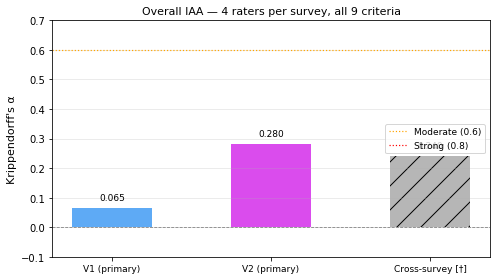

Figure saved → ./Fig/IAA_overall_alpha.png


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Summary table ─────────────────────────────────────────────────────────────
df_iaa_summary = pd.DataFrame({
    "Survey":  ["V1 (primary)", "V2 (primary)", "Cross-survey [†]"],
    "Raters":  ["P1–P4", "P5–P8", "P1–P8 (disconnected)"],
    "Design":  ["Connected", "Connected", "Disconnected"],
    "α":       [iaa_results["V1_combined"], iaa_results["V2_combined"], alpha_cross_combined],
}).set_index("Survey")

print("Krippendorff's Alpha (ordinal) — Overall IAA")
print("=" * 55)
print(df_iaa_summary.round(3).to_string())
print()
print("[†] Disconnected design: V1 and V2 raters evaluated different reports.")
print("    D_e estimated from pooled distributions — treat as indicative only.")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")

labels  = df_iaa_summary.index.tolist()
alphas  = df_iaa_summary["α"].values
colors  = ["#429bf4", "#d42cea", "#aaaaaa"]
hatches = ["", "", "/"]

for i, (label, val, color, hatch) in enumerate(zip(labels, alphas, colors, hatches)):
    bar = ax.bar(i, val, color=color, alpha=0.85, hatch=hatch, width=0.5)
    ax.text(i, val + (0.02 if val >= 0 else -0.06), f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.axhline(0,   color="gray",   linestyle="--", linewidth=0.8)
ax.axhline(0.6, color="orange", linestyle=":",  linewidth=1.2, label="Moderate (0.6)")
ax.axhline(0.8, color="red",    linestyle=":",  linewidth=1.2, label="Strong (0.8)")
ax.set_ylabel("Krippendorff's α", fontsize=11)
ax.set_title("Overall IAA — 4 raters per survey, all 9 criteria", fontsize=11)
ax.set_ylim(-0.1, 0.7)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("./Fig/IAA_overall_alpha.png", dpi=150)
plt.show()
print("Figure saved → ./Fig/IAA_overall_alpha.png")

In [11]:
# Structure reminder:
# df_v1_extracted: (4 raters) × (45 items: R1Q1…R5Q9) + token
# Current compute_alpha() lumps all 9 criteria together.
# Per-criterion: for each Qk, select R1Qk…R5Qk → (4 raters × 5 reports per survey)
# Cross-survey:  V1 (4r×5i) + V2 (4r×5i) → (8r×10i) with NaN off-diagonal blocks
print("df_v1_extracted shape:", df_v1_extracted.shape)
print("columns:", df_v1_extracted.columns.tolist())

df_v1_extracted shape: (4, 46)
columns: ['R1Q1', 'R1Q2', 'R1Q3', 'R1Q4', 'R1Q5', 'R1Q6', 'R1Q7', 'R1Q8', 'R1Q9', 'R2Q1', 'R2Q2', 'R2Q3', 'R2Q4', 'R2Q5', 'R2Q6', 'R2Q7', 'R2Q8', 'R2Q9', 'R3Q1', 'R3Q2', 'R3Q3', 'R3Q4', 'R3Q5', 'R3Q6', 'R3Q7', 'R3Q8', 'R3Q9', 'R4Q1', 'R4Q2', 'R4Q3', 'R4Q4', 'R4Q5', 'R4Q6', 'R4Q7', 'R4Q8', 'R4Q9', 'R5Q1', 'R5Q2', 'R5Q3', 'R5Q4', 'R5Q5', 'R5Q6', 'R5Q7', 'R5Q8', 'R5Q9', 'token']


### Per-Criterion IAA Analysis

Current approach lumps all 9 criteria into one α (4 raters × 45 items).  
Here we compute α **separately for each criterion** Qk using only the 5 report scores for that criterion per survey (4 raters × 5 reports), and cross-survey (8 raters × 10 reports, missing-data handled).

This reveals **which evaluation dimensions are objectively agreeable vs. inherently subjective**.

In [12]:
criteria_labels = {
    "Q1": "Fluidity",
    "Q2": "Conciseness",
    "Q3": "Relevance",
    "Q4": "Coherence",
    "Q5": "Session Info",
    "Q6": "Affective States",
    "Q7": "Results",
    "Q8": "Cognitive Functions",
    "Q9": "Linguistic Indicators",
}


def select_criterion(df, qk):
    """Select columns for criterion qk (e.g. 'Q1') across all reports, plus drop token."""
    cols = [c for c in df.columns if c.endswith(qk) and c != "token"]
    return df[cols]


def compute_alpha_criterion(df, qk):
    sub = select_criterion(df, qk).values.astype(float)
    try:
        return krippendorff.alpha(reliability_data=sub, level_of_measurement="ordinal")
    except (AssertionError, ValueError):
        # Happens when all raters agree perfectly → domain has only 1 value
        # Perfect agreement → α = 1.0 conceptually, but library can't compute it
        return np.nan


def compute_alpha_criterion_combined(df_v1_group, df_v2_group, qk):
    """Cross-survey alpha for one criterion: V1 and V2 raters see different reports."""
    d1 = select_criterion(df_v1_group, qk).values.astype(float)
    d2 = select_criterion(df_v2_group, qk).values.astype(float)
    nr1, ni1 = d1.shape
    nr2, ni2 = d2.shape
    combined = np.full((nr1 + nr2, ni1 + ni2), np.nan)
    combined[:nr1, :ni1] = d1
    combined[nr1:, ni1:] = d2
    try:
        return krippendorff.alpha(reliability_data=combined, level_of_measurement="ordinal")
    except (AssertionError, ValueError):
        return np.nan


# ── Compute per-criterion alpha for every group ───────────────────────────────
rows = []
for qk, label in criteria_labels.items():
    row = {"Criterion": label}
    for survey_label, df_all, df_ortho, df_student in [
        ("V1", df_v1_extracted, df_ortho_v1, df_student_v1),
        ("V2", df_v2_extracted, df_ortho_v2, df_student_v2),
    ]:
        row[f"{survey_label}_all"]        = compute_alpha_criterion(df_all,     qk)
        row[f"{survey_label}_therapists"] = compute_alpha_criterion(df_ortho,   qk)
        row[f"{survey_label}_students"]   = compute_alpha_criterion(df_student, qk)

    row["Cross_all"]        = compute_alpha_criterion_combined(df_v1_extracted, df_v2_extracted, qk)
    row["Cross_therapists"] = compute_alpha_criterion_combined(df_ortho_v1,     df_ortho_v2,     qk)
    row["Cross_students"]   = compute_alpha_criterion_combined(df_student_v1,   df_student_v2,   qk)
    rows.append(row)

df_per_criterion = pd.DataFrame(rows).set_index("Criterion")
print("Krippendorff's α per criterion (ordinal)\n")
print(df_per_criterion.round(3).to_string())

Krippendorff's α per criterion (ordinal)

                       Cross_all  Cross_students  Cross_therapists  V1_all  V1_students  V1_therapists  V2_all  V2_students  V2_therapists
Criterion                                                                                                                                 
Fluidity                   0.276           0.595             0.139  -0.155       -0.043         -0.340   0.564        1.000          0.718
Conciseness               -0.190           0.128            -0.267  -0.141        0.112            NaN  -0.188       -0.286         -0.800
Relevance                  0.058           0.050            -0.272  -0.092        0.107         -0.590   0.009       -0.292          0.213
Coherence                 -0.157          -0.312            -0.454  -0.230       -0.542         -0.687   0.000       -0.500          0.068
Session Info              -0.160          -0.862             0.083  -0.215       -0.740         -0.471  -0.071       -0.800 

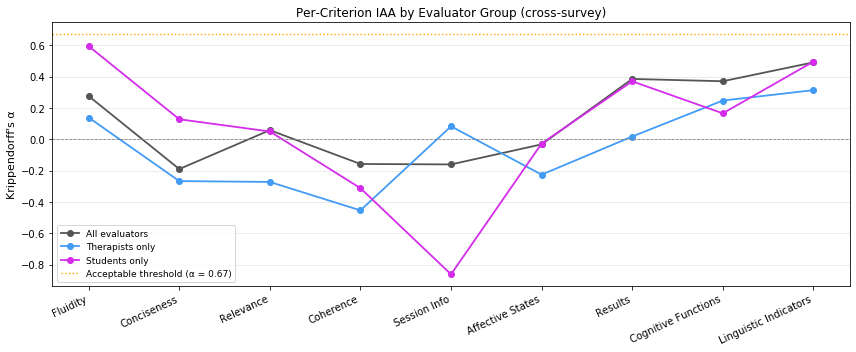

Figure saved → ./Fig/IAA_per_criterion_lineplot.png


In [13]:
# ── Line plot: per-criterion alpha for all three groups ───────────────────────
group_cols  = ["Cross_all", "Cross_therapists", "Cross_students"]
group_titles = ["All evaluators", "Therapists only", "Students only"]

fig2, ax2 = plt.subplots(figsize=(12, 5), facecolor="white")
x = np.arange(len(criteria_labels))
for col, label, color in zip(group_cols, group_titles, ["#555555", "#429bf4", "#d42cea"]):
    ax2.plot(x, df_per_criterion[col].values, marker="o", label=label,
             color=color, linewidth=1.8)

ax2.axhline(0,    color="gray",   linestyle="--", linewidth=0.8)
ax2.axhline(0.67, color="orange", linestyle=":",  linewidth=1.4, label="Acceptable threshold (α = 0.67)")
ax2.set_xticks(x)
ax2.set_xticklabels(criteria_labels.values(), rotation=25, ha="right", fontsize=10)
ax2.set_ylabel("Krippendorff's α", fontsize=11)
ax2.set_title("Per-Criterion IAA by Evaluator Group (cross-survey)", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("./Fig/IAA_per_criterion_lineplot.png", dpi=150)
plt.show()
print("Figure saved → ./Fig/IAA_per_criterion_lineplot.png")

## Therapist vs. Student Scoring Pattern Comparison

The IAA analysis shows that **low agreement is driven by individual variation, not group membership**: therapists are not systematically more consistent with each other than with students. The meaningful question is therefore not *"do therapists agree with each other more?"* but *"do therapists and students apply systematically different standards?"*

To answer this, we compare their **per-criterion mean scores** across all 5 evaluated reports.

**Method**: For each rater, compute the mean score across their 5 reports per criterion → **n=4 therapists** vs. **n=4 students** at the rater level.

Statistics:
- **Mann-Whitney U** (two-sided) — non-parametric, appropriate for ordinal scores with small n.
- **Rank-biserial correlation** r as effect size: r > 0 → therapists scored higher; |r| > 0.5 large, 0.3–0.5 medium.
- ⚠️ With n=4 per group the minimum achievable p ≈ 0.014 (perfect rank separation). Effect size and direction are more informative than p-values.

**Grouping**:
- Therapists (n=4): P1 (V1), P4 (V1), P7 (V2), P8 (V2)
- Students (n=4): P2 (V1), P3 (V1), P5 (V2), P6 (V2)

> **Note on pooling V1+V2**: raters evaluated different report sets, so individual raw scores cannot be directly compared. However, rater-level means aggregate over a roughly balanced mix of Template/GPT-4 reports in both surveys, making the group-level tendency comparable.

In [14]:
from scipy.stats import mannwhitneyu

THERAPIST_TOKENS = {"therapist_01", "therapist_02", "therapist_03", "therapist_04"}

# ── Build per-rater, per-criterion mean score table (long format) ─────────────
records = []
for survey_label, df in [("V1", df_v1_extracted), ("V2", df_v2_extracted)]:
    for _, row in df.iterrows():
        token = row["token"]
        group = "Therapist" if token in THERAPIST_TOKENS else "Student"
        for qk, label in criteria_labels.items():
            cols = [c for c in df.columns if c.endswith(qk) and c != "token"]
            mean_score = row[cols].mean()
            records.append({
                "survey": survey_label, "rater": token, "group": group,
                "criterion": label, "qk": qk, "mean_score": mean_score,
            })

df_rater_means = pd.DataFrame(records)

# ── Mann-Whitney U + rank-biserial correlation per criterion ──────────────────
stat_rows = []
for label in criteria_labels.values():
    sub = df_rater_means[df_rater_means["criterion"] == label]
    t_scores = sub[sub["group"] == "Therapist"]["mean_score"].values
    s_scores = sub[sub["group"] == "Student"]["mean_score"].values

    U, p = mannwhitneyu(t_scores, s_scores, alternative="two-sided")
    # Standard rank-biserial: positive when therapists (first group) score higher
    r_rb = (2 * U) / (len(t_scores) * len(s_scores)) - 1

    stat_rows.append({
        "Criterion":            label,
        "Therapist (mean±SD)":  f"{t_scores.mean():.2f} ± {t_scores.std():.2f}",
        "Student   (mean±SD)":  f"{s_scores.mean():.2f} ± {s_scores.std():.2f}",
        "Diff (T−S)":           round(t_scores.mean() - s_scores.mean(), 2),
        "U":                    int(U),
        "p":                    round(p, 3),
        "r (rank-biserial)":    round(r_rb, 2),
    })

df_stats = pd.DataFrame(stat_rows).set_index("Criterion")

print("Therapist vs. Student — Per-Criterion Mean Scores (n=4 per group)")
print("=" * 80)
print(df_stats.to_string())
print()
print("r interpretation: positive → therapists scored higher; |r|>0.5 large effect.")
print("p-value: minimum achievable ≈ 0.014 with n=4 per group (perfect rank separation).")


Therapist vs. Student — Per-Criterion Mean Scores (n=4 per group)
                       Diff (T−S) Student   (mean±SD) Therapist (mean±SD)   U      p  r (rank-biserial)
Criterion                                                                                              
Fluidity                    -0.45         4.30 ± 0.17         3.85 ± 0.30   1  0.074              -0.81
Conciseness                  0.65         4.10 ± 0.70         4.75 ± 0.26  12  0.243               0.56
Relevance                    0.25         3.75 ± 0.50         4.00 ± 0.98  11  0.465               0.38
Coherence                   -0.20         4.15 ± 0.43         3.95 ± 0.57   6  0.661              -0.25
Session Info                 0.00         3.55 ± 0.67         3.55 ± 0.79   7  1.000              -0.06
Affective States             0.30         3.50 ± 0.36         3.80 ± 0.71  11  0.384               0.44
Results                     -0.45         4.30 ± 0.30         3.85 ± 0.86   6  0.766              -0.1

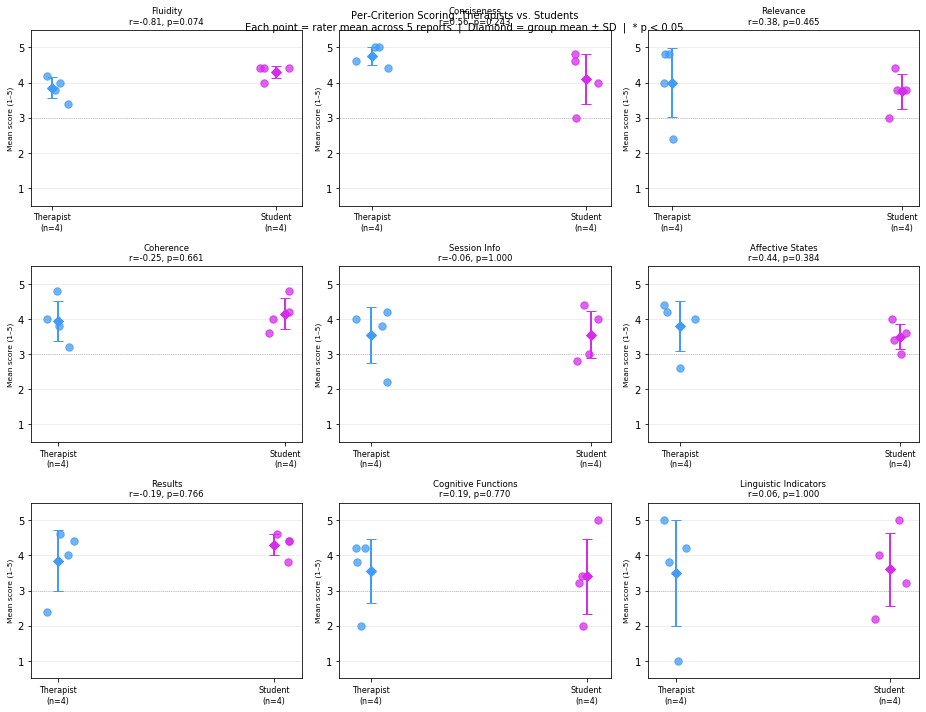

Figure saved → ./Fig/therapist_vs_student_scores.png


In [15]:
criteria_list = list(criteria_labels.values())
fig, axes = plt.subplots(3, 3, figsize=(13, 10), facecolor="white")

GROUP_COLORS = {"Therapist": "#429bf4", "Student": "#d42cea"}
np.random.seed(42)

for ax, criterion in zip(axes.flat, criteria_list):
    for j, group in enumerate(["Therapist", "Student"]):
        scores = df_rater_means[
            (df_rater_means["criterion"] == criterion) &
            (df_rater_means["group"] == group)
        ]["mean_score"].values

        jitter = np.random.uniform(-0.08, 0.08, len(scores))
        ax.scatter([j] * len(scores) + jitter, scores,
                   color=GROUP_COLORS[group], s=55, alpha=0.75, zorder=3)
        ax.errorbar(j, scores.mean(), yerr=scores.std(),
                    fmt="D", color=GROUP_COLORS[group],
                    capsize=5, markersize=7, linewidth=2, zorder=4)

    row = df_stats.loc[criterion]
    sig = "*" if row["p"] < 0.05 else ""
    ax.set_title(f"{criterion}\nr={row['r (rank-biserial)']:.2f}, p={row['p']:.3f}{sig}",
                 fontsize=8.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Therapist\n(n=4)", "Student\n(n=4)"], fontsize=8)
    ax.set_ylim(0.5, 5.5)
    ax.axhline(3, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_ylabel("Mean score (1–5)", fontsize=7.5)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Per-Criterion Scoring: Therapists vs. Students\n"
    "Each point = rater mean across 5 reports  |  Diamond = group mean ± SD  |  * p < 0.05",
    fontsize=10,
)
plt.tight_layout()
plt.savefig("./Fig/therapist_vs_student_scores.png", dpi=150)
plt.show()
print("Figure saved → ./Fig/therapist_vs_student_scores.png")

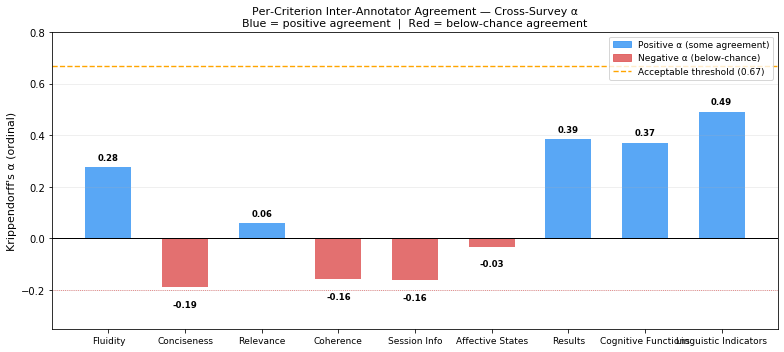

Figure saved → ./Fig/IAA_per_criterion_barchart.png


In [16]:
# ── Fig 1: Per-criterion IAA bar chart (cross-survey α, color = positive/negative) ──
cross_alpha = df_per_criterion["Cross_all"].values
criteria_list_labels = list(criteria_labels.values())

bar_colors = ["#429bf4" if v >= 0 else "#e05c5c" for v in cross_alpha]

fig1, ax1 = plt.subplots(figsize=(11, 5), facecolor="white")
bars = ax1.bar(criteria_list_labels, cross_alpha, color=bar_colors, width=0.6, alpha=0.88)

# value labels on bars
for bar_, val in zip(bars, cross_alpha):
    ypos = val + 0.02 if val >= 0 else val - 0.05
    va   = "bottom" if val >= 0 else "top"
    ax1.text(bar_.get_x() + bar_.get_width() / 2, ypos,
             f"{val:.2f}", ha="center", va=va, fontsize=8.5, fontweight="bold")

# reference lines
ax1.axhline(0,    color="black", linewidth=1.0, linestyle="-")
ax1.axhline(0.67, color="orange", linewidth=1.4, linestyle="--",
            label="Acceptable threshold (α = 0.67)")
ax1.axhline(-0.2, color="#e05c5c", linewidth=0.8, linestyle=":",
            label="Below-chance agreement (α < 0)")

ax1.set_ylabel("Krippendorff's α (ordinal)", fontsize=11)
ax1.set_title("Per-Criterion Inter-Annotator Agreement — Cross-Survey α\n"
              "Blue = positive agreement  |  Red = below-chance agreement", fontsize=11)
ax1.set_ylim(-0.35, 0.80)
ax1.tick_params(axis="x", labelsize=9)
ax1.legend(fontsize=9, loc="upper right")
ax1.grid(axis="y", alpha=0.25)

# colour legend patches
from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#429bf4", alpha=0.88, label="Positive α (some agreement)"),
    Patch(color="#e05c5c", alpha=0.88, label="Negative α (below-chance)"),
]
ax1.legend(handles=legend_handles +
           [plt.Line2D([0], [0], color="orange", linewidth=1.4, linestyle="--",
                       label="Acceptable threshold (0.67)")],
           fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("./Fig/IAA_per_criterion_barchart.png", dpi=150)
plt.show()
print("Figure saved → ./Fig/IAA_per_criterion_barchart.png")

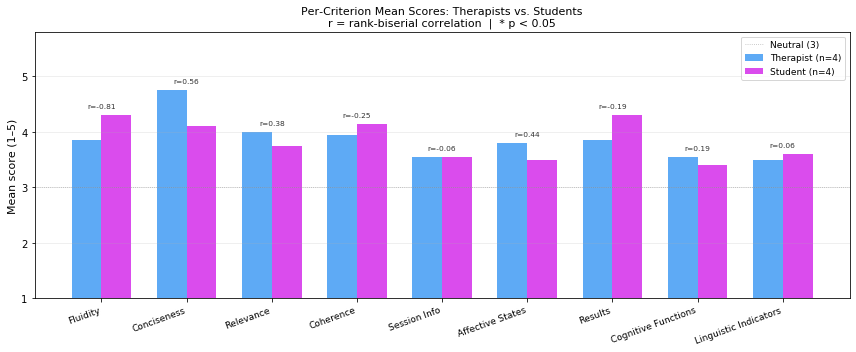

Figure saved → ./Fig/therapist_vs_student_grouped_bar.png


In [17]:
# ── Fig 2: Therapist vs Student — grouped bar chart (9 criteria) ──────────────
group_means = (
    df_rater_means.groupby(["criterion", "group"])["mean_score"]
    .mean()
    .unstack("group")
    .reindex(criteria_list_labels)
)

x = np.arange(len(criteria_list_labels))
w = 0.35

fig2b, ax2b = plt.subplots(figsize=(12, 5), facecolor="white")
b_t = ax2b.bar(x - w / 2, group_means["Therapist"], w,
               label="Therapist (n=4)", color="#429bf4", alpha=0.85)
b_s = ax2b.bar(x + w / 2, group_means["Student"],   w,
               label="Student (n=4)",   color="#d42cea", alpha=0.85)

# annotate effect size r on top
for i, criterion in enumerate(criteria_list_labels):
    r_val = df_stats.loc[criterion, "r (rank-biserial)"]
    p_val = df_stats.loc[criterion, "p"]
    sig   = "*" if p_val < 0.05 else ""
    ymax  = max(group_means.loc[criterion]) + 0.12
    ax2b.text(i, ymax, f"r={r_val:.2f}{sig}", ha="center", fontsize=7.5, color="#333333")

ax2b.set_xticks(x)
ax2b.set_xticklabels(criteria_list_labels, rotation=20, ha="right", fontsize=9)
ax2b.set_ylabel("Mean score (1–5)", fontsize=11)
ax2b.set_ylim(1, 5.8)
ax2b.axhline(3, color="gray", linestyle=":", linewidth=0.8, alpha=0.6, label="Neutral (3)")
ax2b.set_title("Per-Criterion Mean Scores: Therapists vs. Students\n"
               "r = rank-biserial correlation  |  * p < 0.05", fontsize=11)
ax2b.legend(fontsize=9)
ax2b.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("./Fig/therapist_vs_student_grouped_bar.png", dpi=150)
plt.show()
print("Figure saved → ./Fig/therapist_vs_student_grouped_bar.png")

In [18]:
# ── Table 1: LaTeX summary table (α + Mann-Whitney per criterion) ─────────────

def fmt_p(p):
    if p < 0.001:
        return r"$<$0.001"
    elif p < 0.05:
        return f"{p:.3f}*"
    else:
        return f"{p:.3f}"

def fmt_r(r):
    """Bold large effects (|r| >= 0.5)."""
    s = f"{r:.2f}"
    return r"\textbf{" + s + "}" if abs(r) >= 0.5 else s

lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\caption{Per-criterion inter-annotator agreement (Krippendorff's $\alpha$, ordinal, cross-survey)")
lines.append(r"         and therapist vs.\ student scoring comparison (Mann-Whitney $U$, rank-biserial $r$).")
lines.append(r"         Bold $r$ values indicate large effects ($|r| \geq 0.5$). * $p < 0.05$.}")
lines.append(r"\label{tab:iaa_per_criterion}")
lines.append(r"\begin{tabular}{lc cc c cc}")
lines.append(r"\toprule")
lines.append(r" & \multicolumn{1}{c}{IAA} & \multicolumn{2}{c}{Mean score (1--5)} & & \multicolumn{2}{c}{Group comparison} \\")
lines.append(r"\cmidrule(lr){2-2} \cmidrule(lr){3-4} \cmidrule(lr){6-7}")
lines.append(r"Criterion & $\alpha$ & Therapist & Student & $\Delta$~(T$-$S) & $r$ & $p$ \\")
lines.append(r"\midrule")

for criterion in criteria_list_labels:
    alpha_val = df_per_criterion.loc[criterion, "Cross_all"]
    row       = df_stats.loc[criterion]
    t_str     = row["Therapist (mean±SD)"].replace("±", r"$\pm$")
    s_str     = row["Student   (mean±SD)"].replace("±", r"$\pm$")
    diff      = row["Diff (T−S)"]
    r_val     = row["r (rank-biserial)"]
    p_val     = row["p"]

    alpha_str = f"{alpha_val:.2f}" if not np.isnan(alpha_val) else "---"
    diff_str  = f"{diff:+.2f}"
    r_str     = fmt_r(r_val)
    p_str     = fmt_p(p_val)

    lines.append(f"  {criterion} & {alpha_str} & {t_str} & {s_str} & {diff_str} & {r_str} & {p_str} \\\\")

lines.append(r"\midrule")
lines.append(r"\multicolumn{7}{l}{\textit{Note.} $\alpha$: Krippendorff's $\alpha$ (cross-survey, disconnected design, indicative only).} \\")
lines.append(r"\multicolumn{7}{l}{$r$: rank-biserial correlation; positive = therapists scored higher.} \\")
lines.append(r"\multicolumn{7}{l}{Min.\ achievable $p \approx 0.014$ with $n=4$ per group (perfect rank separation).} \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\small
\caption{Per-criterion inter-annotator agreement (Krippendorff's $\alpha$, ordinal, cross-survey)
         and therapist vs.\ student scoring comparison (Mann-Whitney $U$, rank-biserial $r$).
         Bold $r$ values indicate large effects ($|r| \geq 0.5$). * $p < 0.05$.}
\label{tab:iaa_per_criterion}
\begin{tabular}{lc cc c cc}
\toprule
 & \multicolumn{1}{c}{IAA} & \multicolumn{2}{c}{Mean score (1--5)} & & \multicolumn{2}{c}{Group comparison} \\
\cmidrule(lr){2-2} \cmidrule(lr){3-4} \cmidrule(lr){6-7}
Criterion & $\alpha$ & Therapist & Student & $\Delta$~(T$-$S) & $r$ & $p$ \\
\midrule
  Fluidity & 0.28 & 3.85 $\pm$ 0.30 & 4.30 $\pm$ 0.17 & -0.45 & \textbf{-0.81} & 0.074 \\
  Conciseness & -0.19 & 4.75 $\pm$ 0.26 & 4.10 $\pm$ 0.70 & +0.65 & \textbf{0.56} & 0.243 \\
  Relevance & 0.06 & 4.00 $\pm$ 0.98 & 3.75 $\pm$ 0.50 & +0.25 & 0.38 & 0.465 \\
  Coherence & -0.16 & 3.95 $\pm$ 0.57 & 4.15 $\pm$ 0.43 & -0.20 & -0.25 & 0.661 \\
  Session Info & -0.16 

## System x Rater-Group Reconciliation

The table above pools each rater's mean score across all 5 reports before
comparing Therapist vs. Student scoring. Since each survey mixes Template- and
GPT-4-generated reports, this pooled comparison can combine two different underlying
effects. The cell below splits each rater's mean score by report-generation system
*before* running the same Mann-Whitney U / rank-biserial r procedure, to check whether
a pooled effect is concentrated in one system, present in both, or cancels out between
systems (opposite-sign effects on Template vs. GPT-4 reports).


In [19]:
# ── System (Template/GPT-4) x Rater-group (Therapist/Student) x Criterion ──
# Builds one long-format table, then derives:
#   View A: mean score by System, within All / Therapists / Students
#   View B: Therapist vs Student comparison, split by System
# using the same per-rater-mean methodology as the pooled comparison above
# (mean_score = row[cols].mean(), n=4 vs n=4).

from scipy.stats import mannwhitneyu

THERAPIST_TOKENS = {"therapist_01", "therapist_02", "therapist_03", "therapist_04"}

# R-slot -> system, per survey.
SYSTEM_BY_SLOT = {
    "V1": {"R1": "Template", "R2": "GPT-4", "R3": "Template", "R4": "GPT-4",  "R5": "Template"},
    "V2": {"R1": "Template", "R2": "GPT-4", "R3": "GPT-4",    "R4": "Template", "R5": "GPT-4"},
}

# ── Raw long-format table (one row per rater x report-slot x criterion) ───────
records = []
for survey_label, df in [("V1", df_v1_extracted), ("V2", df_v2_extracted)]:
    for _, row in df.iterrows():
        token = row["token"]
        rater_group = "Therapist" if token in THERAPIST_TOKENS else "Student"
        for slot, system in SYSTEM_BY_SLOT[survey_label].items():
            for qk, label in criteria_labels.items():
                col = f"{slot}{qk}"
                if col not in df.columns:
                    continue
                records.append({
                    "survey": survey_label, "rater": token, "rater_group": rater_group,
                    "system": system, "slot": slot, "criterion": label, "qk": qk,
                    "score": row[col],
                })

df_full = pd.DataFrame(records)

# ── View A: mean score by System, for All / Therapists / Students ─────────────
view_a_all = (
    df_full.groupby(["criterion", "system"])["score"]
    .agg(["mean", "std"])
    .round(2)
)
print("View A — ALL evaluators, Template vs GPT-4:")
print(view_a_all.to_string())
print()

view_a_therapists = (
    df_full[df_full["rater_group"] == "Therapist"]
    .groupby(["criterion", "system"])["score"]
    .agg(["mean", "std"])
    .round(2)
)
print("View A — THERAPISTS only, Template vs GPT-4:")
print(view_a_therapists.to_string())
print()

view_a_students = (
    df_full[df_full["rater_group"] == "Student"]
    .groupby(["criterion", "system"])["score"]
    .agg(["mean", "std"])
    .round(2)
)
print("View A — STUDENTS only, Template vs GPT-4:")
print(view_a_students.to_string())
print()

# ── Per-rater, per-criterion, per-system mean score ────────────────────────────
rater_system_means = (
    df_full.groupby(["rater", "rater_group", "system", "criterion"])["score"]
    .mean()
    .reset_index()
    .rename(columns={"score": "mean_score"})
)

# ── View B split by system: Mann-Whitney U / rank-biserial r, Therapist vs Student,
#    computed separately within Template and within GPT-4 ─────────────────────
stat_rows = []
for system in ["Template", "GPT-4"]:
    for label in criteria_labels.values():
        sub = rater_system_means[
            (rater_system_means["system"] == system) & (rater_system_means["criterion"] == label)
        ]
        t_scores = sub[sub["rater_group"] == "Therapist"]["mean_score"].values
        s_scores = sub[sub["rater_group"] == "Student"]["mean_score"].values

        U, p = mannwhitneyu(t_scores, s_scores, alternative="two-sided")
        r_rb = (2 * U) / (len(t_scores) * len(s_scores)) - 1

        stat_rows.append({
            "Criterion": label,
            "System": system,
            "Therapist (mean±SD)": f"{t_scores.mean():.2f} ± {t_scores.std():.2f}",
            "Student (mean±SD)":   f"{s_scores.mean():.2f} ± {s_scores.std():.2f}",
            "U": round(U, 1),
            "p": round(p, 3),
            "r (rank-biserial)": round(r_rb, 2),
        })

df_stats_by_system = pd.DataFrame(stat_rows).set_index(["Criterion", "System"])
print("View B split by system — Therapist vs Student, Mann-Whitney U (n=4 vs n=4 per system):")
print(df_stats_by_system.to_string())


View A — ALL evaluators, Template vs GPT-4:
                                mean   std
criterion             system              
Affective States      GPT-4     3.70  1.13
                      Template  3.60  0.94
Cognitive Functions   GPT-4     3.45  1.00
                      Template  3.50  1.19
Coherence             GPT-4     3.85  0.88
                      Template  4.25  0.72
Conciseness           GPT-4     4.70  0.47
                      Template  4.15  1.18
Fluidity              GPT-4     3.65  1.27
                      Template  4.50  0.61
Linguistic Indicators GPT-4     3.85  1.27
                      Template  3.25  1.52
Relevance             GPT-4     3.90  0.97
                      Template  3.85  1.04
Results               GPT-4     3.70  1.30
                      Template  4.45  0.94
Session Info          GPT-4     3.45  1.00
                      Template  3.65  0.81

View A — THERAPISTS only, Template vs GPT-4:
                                mean   std
criteri